In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = str(os.cpu_count() or 4)

# monkeypatch joblib's bundled loky to skip wmic CPU detection on Windows
# _count_physical_cores returns (core_count, exception)
try:
    import joblib.externals.loky.backend.context as _loky_ctx
    _n = os.cpu_count() or 4
    _loky_ctx._count_physical_cores = lambda: (_n, None)
except Exception:
    pass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LassoCV, RidgeCV, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb

RATED_CAPACITY = 2.0  # Ah
EOL_THRESHOLD = 1.4   # Ah (30% fade from rated)
BASE = 'NASA_Cleaned_Dataset'
print('Imports done')

Imports done


In [2]:
# load metadata and convert types
meta = pd.read_csv(f'{BASE}/metadata.csv')
meta['Capacity'] = pd.to_numeric(meta['Capacity'], errors='coerce')
meta['Re'] = pd.to_numeric(meta['Re'], errors='coerce')
meta['Rct'] = pd.to_numeric(meta['Rct'], errors='coerce')

# feature extraction from discharge cycles
def extract_cycle_features(meta_df, base_path, battery_id):
    dis = meta_df[(meta_df.battery_id == battery_id) & (meta_df.type == 'discharge') & (meta_df.Capacity.notna())]
    imp = meta_df[(meta_df.battery_id == battery_id) & (meta_df.type == 'impedance')]
    
    features = []
    for idx, (_, row) in enumerate(dis.iterrows()):
        try:
            df = pd.read_csv(f"{base_path}/data/{row['filename']}")
        except:
            continue
        
        v = df['Voltage_measured']
        i = df['Current_measured']
        t = df['Temperature_measured']
        time = df['Time']
        
        feat = {
            'battery_id': battery_id,
            'cycle': idx,
            'capacity': row['Capacity'],
            'v_mean': v.mean(), 'v_std': v.std(), 'v_min': v.min(),
            'v_max': v.max(), 'v_range': v.max() - v.min(),
            'i_mean': i.mean(), 'i_std': i.std(), 'i_min': i.min(), 'i_max': i.max(),
            't_mean': t.mean(), 't_std': t.std(), 't_max': t.max(), 't_rise': t.max() - t.iloc[0],
            'discharge_time': time.max(),
            'energy': np.trapz(v.values * np.abs(i.values), time.values) / 3600,
        }
        
        prior_imp = imp[imp.uid < row['uid']]
        if len(prior_imp) > 0:
            last_imp = prior_imp.iloc[-1]
            feat['Re'] = last_imp['Re'] if pd.notna(last_imp['Re']) else np.nan
            feat['Rct'] = last_imp['Rct'] if pd.notna(last_imp['Rct']) else np.nan
        else:
            feat['Re'] = np.nan
            feat['Rct'] = np.nan
        
        features.append(feat)
    return pd.DataFrame(features)

# extract for all batteries, filter bad ones
all_features = []
for bid in sorted(meta.battery_id.unique()):
    bf = extract_cycle_features(meta, BASE, bid)
    if len(bf) < 10:
        continue
    cap_fade = (bf.capacity.iloc[0] - bf.capacity.iloc[-1]) / bf.capacity.iloc[0] * 100
    if bf.capacity.iloc[0] < 0.5 or cap_fade < -20:
        print(f'  SKIPPED {bid}: cap_start={bf.capacity.iloc[0]:.3f}, fade={cap_fade:.1f}%')
        continue
    all_features.append(bf)
    print(f'{bid}: {len(bf)} cycles, cap {bf.capacity.iloc[0]:.3f} -> {bf.capacity.iloc[-1]:.3f} Ah, fade {cap_fade:.1f}%')

df_all = pd.concat(all_features, ignore_index=True)
print(f'\nTotal samples: {len(df_all)}, Batteries: {df_all.battery_id.nunique()}')

B0005: 168 cycles, cap 1.856 -> 1.325 Ah, fade 28.6%
B0006: 168 cycles, cap 2.035 -> 1.186 Ah, fade 41.7%
B0007: 168 cycles, cap 1.891 -> 1.432 Ah, fade 24.3%
B0018: 132 cycles, cap 1.855 -> 1.341 Ah, fade 27.7%
B0025: 28 cycles, cap 1.847 -> 1.768 Ah, fade 4.3%
B0026: 28 cycles, cap 1.813 -> 1.769 Ah, fade 2.5%
B0027: 28 cycles, cap 1.823 -> 1.770 Ah, fade 2.9%
B0028: 28 cycles, cap 1.805 -> 1.717 Ah, fade 4.8%
B0029: 40 cycles, cap 1.698 -> 1.612 Ah, fade 5.0%
B0030: 40 cycles, cap 1.656 -> 1.563 Ah, fade 5.6%
B0031: 40 cycles, cap 1.667 -> 1.667 Ah, fade -0.0%
B0032: 40 cycles, cap 1.705 -> 1.636 Ah, fade 4.1%
  SKIPPED B0033: cap_start=0.068, fade=-1822.2%
  SKIPPED B0034: cap_start=0.746, fade=-71.6%
  SKIPPED B0036: cap_start=1.002, fade=-55.6%
  SKIPPED B0038: cap_start=0.898, fade=-70.4%
  SKIPPED B0039: cap_start=0.119, fade=-1005.0%
B0040: 47 cycles, cap 0.673 -> 0.557 Ah, fade 17.3%
  SKIPPED B0041: cap_start=0.056, fade=-1403.9%
B0042: 112 cycles, cap 1.729 -> 1.337 Ah, fad

In [3]:
# compute RUL: cycles remaining until capacity <= EOL_THRESHOLD
# for batteries that never reach EOL, use last cycle as proxy
def add_rul(df, eol_threshold=EOL_THRESHOLD):
    result = []
    for bid in df.battery_id.unique():
        bdf = df[df.battery_id == bid].copy()
        eol_rows = bdf[bdf.capacity <= eol_threshold]
        if len(eol_rows) > 0:
            eol_cycle = eol_rows.iloc[0]['cycle']
            reached_eol = True
        else:
            eol_cycle = bdf['cycle'].max()
            reached_eol = False
        bdf['RUL'] = eol_cycle - bdf['cycle']
        bdf['SoH'] = bdf['capacity'] / RATED_CAPACITY * 100
        bdf['reached_eol'] = reached_eol
        result.append(bdf)
    return pd.concat(result, ignore_index=True)

df_all = add_rul(df_all)

# clip RUL at 0 (don't use post-EOL data for training)
pre_clip = len(df_all)
df_all = df_all[df_all.RUL >= 0].copy()
print(f'Removed {pre_clip - len(df_all)} post-EOL samples (RUL < 0)')

# EOL status per battery
for bid in df_all.battery_id.unique():
    bdf = df_all[df_all.battery_id == bid]
    eol_str = 'reached EOL' if bdf.reached_eol.iloc[0] else 'did NOT reach EOL'
    print(f'{bid}: {len(bdf)} cycles, RUL {bdf.RUL.max()} -> {bdf.RUL.min()}, {eol_str}')

print(f'\nTotal samples: {len(df_all)}')
print(f'RUL range: {df_all.RUL.min()} to {df_all.RUL.max()} cycles')

Removed 996 post-EOL samples (RUL < 0)
B0005: 125 cycles, RUL 124 -> 0, reached EOL
B0006: 109 cycles, RUL 108 -> 0, reached EOL
B0007: 168 cycles, RUL 167 -> 0, did NOT reach EOL
B0018: 97 cycles, RUL 96 -> 0, reached EOL
B0025: 28 cycles, RUL 27 -> 0, did NOT reach EOL
B0026: 6 cycles, RUL 5 -> 0, reached EOL
B0027: 28 cycles, RUL 27 -> 0, did NOT reach EOL
B0028: 28 cycles, RUL 27 -> 0, did NOT reach EOL
B0029: 40 cycles, RUL 39 -> 0, did NOT reach EOL
B0030: 40 cycles, RUL 39 -> 0, did NOT reach EOL
B0031: 40 cycles, RUL 39 -> 0, did NOT reach EOL
B0032: 40 cycles, RUL 39 -> 0, did NOT reach EOL
B0040: 1 cycles, RUL 0 -> 0, reached EOL
B0042: 6 cycles, RUL 5 -> 0, reached EOL
B0043: 6 cycles, RUL 5 -> 0, reached EOL
B0044: 6 cycles, RUL 5 -> 0, reached EOL
B0045: 1 cycles, RUL 0 -> 0, reached EOL
B0046: 17 cycles, RUL 16 -> 0, reached EOL
B0047: 10 cycles, RUL 9 -> 0, reached EOL
B0048: 12 cycles, RUL 11 -> 0, reached EOL
B0049: 1 cycles, RUL 0 -> 0, reached EOL
B0050: 1 cycles, RU

In [4]:
# handle missing impedance
df_all['Re'] = df_all.groupby('battery_id')['Re'].ffill()
df_all['Rct'] = df_all.groupby('battery_id')['Rct'].bfill()
df_all['Re'] = df_all.groupby('battery_id')['Re'].bfill()
df_all['Rct'] = df_all.groupby('battery_id')['Rct'].bfill()
df_all = df_all.dropna(subset=['Re', 'Rct'])

# === DEGRADATION RATE FEATURES ===
for w in [3, 5]:
    df_all[f'cap_roll{w}'] = df_all.groupby('battery_id')['capacity'].transform(
        lambda x: x.rolling(w, min_periods=1).mean())
    df_all[f'cap_std{w}'] = df_all.groupby('battery_id')['capacity'].transform(
        lambda x: x.rolling(w, min_periods=1).std().fillna(0))

df_all['SoH_delta'] = df_all.groupby('battery_id')['SoH'].diff().fillna(0)
df_all['cap_delta'] = df_all.groupby('battery_id')['capacity'].diff().fillna(0)
df_all['Re_delta'] = df_all.groupby('battery_id')['Re'].diff().fillna(0)
df_all['energy_delta'] = df_all.groupby('battery_id')['energy'].diff().fillna(0)

df_all['SoH_rate'] = df_all.groupby('battery_id').apply(
    lambda g: (g['SoH'].iloc[0] - g['SoH']) / (g['cycle'] - g['cycle'].iloc[0] + 1)
).reset_index(level=0, drop=True)

df_all['cap_fade'] = df_all.groupby('battery_id')['capacity'].transform(
    lambda x: (x.iloc[0] - x) / x.iloc[0])

# === LAG FEATURES (trajectory memory) ===
for lag in [1, 2, 3]:
    df_all[f'SoH_lag{lag}'] = df_all.groupby('battery_id')['SoH'].shift(lag)
    df_all[f'cap_lag{lag}'] = df_all.groupby('battery_id')['capacity'].shift(lag)
    if lag <= 2:
        df_all[f'Re_lag{lag}'] = df_all.groupby('battery_id')['Re'].shift(lag)

# fill first rows (no history) with current values
for lag in [1, 2, 3]:
    df_all[f'SoH_lag{lag}'] = df_all[f'SoH_lag{lag}'].fillna(df_all['SoH'])
    df_all[f'cap_lag{lag}'] = df_all[f'cap_lag{lag}'].fillna(df_all['capacity'])
    if lag <= 2:
        df_all[f'Re_lag{lag}'] = df_all[f'Re_lag{lag}'].fillna(df_all['Re'])

# === INTERACTION FEATURES ===
# SoH × degradation rate = "how far gone" × "how fast declining"
df_all['SoH_x_rate'] = df_all['SoH'] * df_all['SoH_rate']
df_all['SoH_x_delta'] = df_all['SoH'] * df_all['SoH_delta']
df_all['cap_x_Re'] = df_all['capacity'] * df_all['Re']  # capacity × internal resistance

# squared terms for key features (captures nonlinearity for linear models)
df_all['SoH_sq'] = df_all['SoH'] ** 2
df_all['cap_fade_sq'] = df_all['cap_fade'] ** 2

feature_cols = ['cycle', 'SoH', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_range',
                'i_mean', 'i_std', 'i_min', 'i_max',
                't_mean', 't_std', 't_max', 't_rise',
                'discharge_time', 'energy', 'Re', 'Rct',
                # degradation rate features
                'SoH_delta', 'cap_delta', 'Re_delta', 'energy_delta',
                'SoH_rate', 'cap_fade',
                'cap_roll3', 'cap_roll5', 'cap_std3', 'cap_std5',
                # lag features
                'SoH_lag1', 'SoH_lag2', 'SoH_lag3',
                'cap_lag1', 'cap_lag2', 'cap_lag3',
                'Re_lag1', 'Re_lag2',
                # interaction + nonlinear features
                'SoH_x_rate', 'SoH_x_delta', 'cap_x_Re',
                'SoH_sq', 'cap_fade_sq']
target_col = 'RUL'

print(f'Features: {len(feature_cols)}')

corr = df_all[feature_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print('\nTop correlations with RUL:')
for feat, val in corr.items():
    print(f'  {feat:20s}: {val:+.4f}')

Features: 42

Top correlations with RUL:
  energy              : +0.6772
  v_mean              : +0.5722
  cap_roll5           : +0.5314
  cap_roll3           : +0.5289
  SoH_sq              : +0.5262
  SoH_lag1            : +0.5225
  cap_lag1            : +0.5225
  SoH_lag2            : +0.5209
  cap_lag2            : +0.5209
  SoH_lag3            : +0.5203
  cap_lag3            : +0.5203
  SoH                 : +0.4751
  Re_lag2             : -0.4544
  Re_lag1             : -0.4528
  i_std               : -0.4523
  Re                  : -0.4503
  i_min               : +0.3531
  Rct                 : -0.3531
  cap_x_Re            : -0.2494
  i_max               : -0.2268
  cap_fade            : -0.1860
  cap_fade_sq         : -0.1707
  t_mean              : -0.1700
  v_std               : -0.1452
  t_max               : -0.1429
  v_range             : +0.1378
  cycle               : -0.1374
  v_min               : -0.1326
  v_max               : +0.1243
  i_mean              : +0.1121

In [5]:
# hybrid split: ALL cycles from non-classic batteries + first 70% of classic = train
# last 30% of classic batteries = test (avoids distribution shift)
classic = ['B0005', 'B0006', 'B0007', 'B0018']

train_rows, test_rows = [], []
for bid in sorted(df_all.battery_id.unique()):
    bdf = df_all[df_all.battery_id == bid].sort_values('cycle')
    if bid in classic:
        n = len(bdf)
        split = int(n * 0.7)
        train_rows.append(bdf.iloc[:split])
        test_rows.append(bdf.iloc[split:])
    else:
        train_rows.append(bdf)

train_df = pd.concat(train_rows, ignore_index=True)
test_df = pd.concat(test_rows, ignore_index=True)

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values
groups_train = train_df['battery_id'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

n_other = len([b for b in df_all.battery_id.unique() if b not in classic])
print(f'Train: {len(train_df)} samples ({train_df.battery_id.nunique()} batteries)')
print(f'  - All cycles from {n_other} non-classic batteries')
print(f'  - First 70% from classic: {classic}')
print(f'Test:  {len(test_df)} samples (last 30% of {classic})')
print(f'\nTrain RUL: {y_train.min():.0f} to {y_train.max():.0f} cycles')
print(f'Test RUL:  {y_test.min():.0f} to {y_test.max():.0f} cycles')

Train: 654 samples (18 batteries)
  - All cycles from 14 non-classic batteries
  - First 70% from classic: ['B0005', 'B0006', 'B0007', 'B0018']
Test:  152 samples (last 30% of ['B0005', 'B0006', 'B0007', 'B0018'])

Train RUL: 0 to 167 cycles
Test RUL:  0 to 50 cycles


In [6]:
# ============================================================
# ROUND 1: Baseline Models (tree models constrained to prevent overfitting)
# ============================================================
r1_models = {
    'RidgeCV': RidgeCV(alphas=np.logspace(-2, 4, 50)),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    'KNN': KNeighborsRegressor(n_neighbors=9, weights='distance'),
    'SVR': SVR(kernel='rbf', C=10, epsilon=0.5),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=15,
        max_features=0.5, random_state=42),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=15,
        max_features=0.5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=150, max_depth=3, min_samples_leaf=15,
        learning_rate=0.05, subsample=0.8, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, learning_rate=0.05, random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000,
                        alpha=1.0, early_stopping=True, random_state=42),
}

results = {}
all_preds = {}

for name, model in r1_models.items():
    model.fit(X_train_s, y_train)
    y_pred_train = model.predict(X_train_s)
    y_pred_test = model.predict(X_test_s)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    results[name] = {
        'Round': 'R1', 'R2_train': r2_train, 'R2_test': r2_test,
        'MAE': mae_test, 'RMSE': rmse_test, 'Overfit': r2_train - r2_test
    }
    all_preds[name] = y_pred_test
    print(f'{name:25s} | R2: {r2_test:.4f} | MAE: {mae_test:.1f} cycles | RMSE: {rmse_test:.1f} cycles | Overfit: {r2_train - r2_test:+.4f}')

r1_best = max(results, key=lambda k: results[k]['R2_test'])
print(f'\nR1 Best: {r1_best} (R2={results[r1_best]["R2_test"]:.4f})')

RidgeCV                   | R2: 0.8467 | MAE: 4.0 cycles | RMSE: 4.9 cycles | Overfit: +0.0967
Lasso                     | R2: 0.1325 | MAE: 10.4 cycles | RMSE: 11.6 cycles | Overfit: +0.7764
ElasticNet                | R2: -0.1755 | MAE: 12.0 cycles | RMSE: 13.5 cycles | Overfit: +1.0674
KNN                       | R2: -3.7298 | MAE: 24.2 cycles | RMSE: 27.1 cycles | Overfit: +4.7298
SVR                       | R2: -0.4416 | MAE: 13.2 cycles | RMSE: 15.0 cycles | Overfit: +1.4203
Random Forest             | R2: -3.6119 | MAE: 24.7 cycles | RMSE: 26.8 cycles | Overfit: +4.5812
Extra Trees               | R2: -5.5347 | MAE: 29.7 cycles | RMSE: 31.8 cycles | Overfit: +6.4766
Gradient Boosting         | R2: -2.2281 | MAE: 20.2 cycles | RMSE: 22.4 cycles | Overfit: +3.2240
AdaBoost                  | R2: -4.4910 | MAE: 27.0 cycles | RMSE: 29.2 cycles | Overfit: +5.4316
MLP                       | R2: -0.4607 | MAE: 13.0 cycles | RMSE: 15.1 cycles | Overfit: +1.4497

R1 Best: RidgeCV (R2=0.

In [7]:
# ============================================================
# ROUND 2: XGBoost Tuning (constrained for small dataset)
# ============================================================
gkf = GroupKFold(n_splits=min(5, len(np.unique(groups_train))))

xgb_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'min_child_weight': [5, 10, 20],
    'reg_alpha': [0.1, 1.0, 5.0, 10.0],
    'reg_lambda': [1.0, 5.0, 10.0],
    'gamma': [0, 0.1, 0.5, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    xgb_params, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_s, y_train, groups=groups_train)
xgb_best = xgb_search.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_s)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

results['XGBoost (tuned)'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, xgb_best.predict(X_train_s)),
    'R2_test': r2_xgb, 'MAE': mae_xgb, 'RMSE': rmse_xgb,
    'Overfit': r2_score(y_train, xgb_best.predict(X_train_s)) - r2_xgb
}
all_preds['XGBoost (tuned)'] = y_pred_xgb
print(f'XGBoost (tuned)           | R2: {r2_xgb:.4f} | MAE: {mae_xgb:.1f} cycles | RMSE: {rmse_xgb:.1f} cycles')
print(f'  Best params: {xgb_search.best_params_}')

XGBoost (tuned)           | R2: -2.2757 | MAE: 20.2 cycles | RMSE: 22.5 cycles
  Best params: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 20, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.5}


In [8]:
# LightGBM tuning (constrained for small dataset)
lgb_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [7, 15, 20],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'min_child_samples': [10, 20, 30],
    'reg_alpha': [0.1, 1.0, 5.0, 10.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbosity=-1),
    lgb_params, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1
)
lgb_search.fit(X_train_s, y_train, groups=groups_train)
lgb_best = lgb_search.best_estimator_

y_pred_lgb = lgb_best.predict(X_test_s)
r2_lgb = r2_score(y_test, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

results['LightGBM (tuned)'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, lgb_best.predict(X_train_s)),
    'R2_test': r2_lgb, 'MAE': mae_lgb, 'RMSE': rmse_lgb,
    'Overfit': r2_score(y_train, lgb_best.predict(X_train_s)) - r2_lgb
}
all_preds['LightGBM (tuned)'] = y_pred_lgb
print(f'LightGBM (tuned)          | R2: {r2_lgb:.4f} | MAE: {mae_lgb:.1f} cycles | RMSE: {rmse_lgb:.1f} cycles')
print(f'  Best params: {lgb_search.best_params_}')

LightGBM (tuned)          | R2: -1.8471 | MAE: 18.6 cycles | RMSE: 21.0 cycles
  Best params: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.5}


In [9]:
# R2 Ensemble
r1_best_model = r1_models[r1_best]

oof_r1 = cross_val_predict(r1_best_model, X_train_s, y_train, cv=gkf, groups=groups_train)
oof_xgb = cross_val_predict(xgb_best, X_train_s, y_train, cv=gkf, groups=groups_train)
oof_lgb = cross_val_predict(lgb_best, X_train_s, y_train, cv=gkf, groups=groups_train)

oof_stack = np.column_stack([oof_r1, oof_xgb, oof_lgb])
test_stack = np.column_stack([all_preds[r1_best], y_pred_xgb, y_pred_lgb])

def ensemble_loss(w):
    return mean_squared_error(y_train, oof_stack @ w)

res = minimize(ensemble_loss, x0=[1/3, 1/3, 1/3],
               constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
               bounds=[(0, 1)] * 3, method='SLSQP')
w_opt = res.x
print(f'Optimal weights: {r1_best}={w_opt[0]:.3f}, XGBoost={w_opt[1]:.3f}, LightGBM={w_opt[2]:.3f}')

y_pred_ens = test_stack @ w_opt
r2_ens = r2_score(y_test, y_pred_ens)
mae_ens = mean_absolute_error(y_test, y_pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ens))
results['Weighted Ensemble'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, oof_stack @ w_opt),
    'R2_test': r2_ens, 'MAE': mae_ens, 'RMSE': rmse_ens,
    'Overfit': r2_score(y_train, oof_stack @ w_opt) - r2_ens
}
all_preds['Weighted Ensemble'] = y_pred_ens
print(f'Weighted Ensemble         | R2: {r2_ens:.4f} | MAE: {mae_ens:.1f} cycles | RMSE: {rmse_ens:.1f} cycles')

y_pred_avg = test_stack.mean(axis=1)
r2_avg = r2_score(y_test, y_pred_avg)
mae_avg = mean_absolute_error(y_test, y_pred_avg)
rmse_avg = np.sqrt(mean_squared_error(y_test, y_pred_avg))
results['Simple Average'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, oof_stack.mean(axis=1)),
    'R2_test': r2_avg, 'MAE': mae_avg, 'RMSE': rmse_avg,
    'Overfit': r2_score(y_train, oof_stack.mean(axis=1)) - r2_avg
}
all_preds['Simple Average'] = y_pred_avg
print(f'Simple Average            | R2: {r2_avg:.4f} | MAE: {mae_avg:.1f} cycles | RMSE: {rmse_avg:.1f} cycles')

Optimal weights: RidgeCV=0.000, XGBoost=0.000, LightGBM=1.000
Weighted Ensemble         | R2: -1.8471 | MAE: 18.6 cycles | RMSE: 21.0 cycles
Simple Average            | R2: -0.5364 | MAE: 13.8 cycles | RMSE: 15.4 cycles


In [10]:
# ============================================================
# ROUND 3: Spline Features + Feature Selection + Stacking
# ============================================================
from sklearn.preprocessing import SplineTransformer
from sklearn.feature_selection import mutual_info_regression

# --- Feature selection: keep top features by mutual information ---
mi_scores = mutual_info_regression(X_train_s, y_train, random_state=42)
mi_rank = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
print('Mutual Information scores:')
for feat, val in mi_rank.items():
    print(f'  {feat:20s}: {val:.4f}')

# keep features with MI > 0.1
top_mi = mi_rank[mi_rank > 0.1].index.tolist()
print(f'\nSelected {len(top_mi)} features by MI > 0.1: {top_mi}')

top_idx = [feature_cols.index(f) for f in top_mi]
X_train_sel = X_train_s[:, top_idx]
X_test_sel = X_test_s[:, top_idx]

# --- RidgeCV on selected features only ---
ridge_sel = RidgeCV(alphas=np.logspace(-2, 4, 50))
ridge_sel.fit(X_train_sel, y_train)
y_pred_sel = ridge_sel.predict(X_test_sel)
r2_sel = r2_score(y_test, y_pred_sel)
mae_sel = mean_absolute_error(y_test, y_pred_sel)
rmse_sel = np.sqrt(mean_squared_error(y_test, y_pred_sel))
results['RidgeCV (MI-select)'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, ridge_sel.predict(X_train_sel)),
    'R2_test': r2_sel, 'MAE': mae_sel, 'RMSE': rmse_sel,
    'Overfit': r2_score(y_train, ridge_sel.predict(X_train_sel)) - r2_sel
}
all_preds['RidgeCV (MI-select)'] = y_pred_sel
print(f'\nRidgeCV (MI-select)       | R2: {r2_sel:.4f} | MAE: {mae_sel:.1f} | RMSE: {rmse_sel:.1f} | alpha={ridge_sel.alpha_:.2f}')

# --- Spline features on top correlated features ---
top_corr_feats = corr.abs().sort_values(ascending=False).head(8).index.tolist()
print(f'\nTop 8 for splines: {top_corr_feats}')
corr_idx = [feature_cols.index(f) for f in top_corr_feats]
X_train_corr = X_train_s[:, corr_idx]
X_test_corr = X_test_s[:, corr_idx]

spline = SplineTransformer(n_knots=5, degree=3, include_bias=False)
X_train_spl = spline.fit_transform(X_train_corr)
X_test_spl = spline.transform(X_test_corr)

# combine: all original scaled features + spline features
X_train_aug = np.hstack([X_train_s, X_train_spl])
X_test_aug = np.hstack([X_test_s, X_test_spl])
print(f'Spline features: {X_train_spl.shape[1]}, Total augmented: {X_train_aug.shape[1]}')

ridge_spl = RidgeCV(alphas=np.logspace(-2, 5, 60))
ridge_spl.fit(X_train_aug, y_train)
y_pred_spl = ridge_spl.predict(X_test_aug)
r2_spl = r2_score(y_test, y_pred_spl)
mae_spl = mean_absolute_error(y_test, y_pred_spl)
rmse_spl = np.sqrt(mean_squared_error(y_test, y_pred_spl))
results['RidgeCV (spline)'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, ridge_spl.predict(X_train_aug)),
    'R2_test': r2_spl, 'MAE': mae_spl, 'RMSE': rmse_spl,
    'Overfit': r2_score(y_train, ridge_spl.predict(X_train_aug)) - r2_spl
}
all_preds['RidgeCV (spline)'] = y_pred_spl
print(f'RidgeCV (spline)          | R2: {r2_spl:.4f} | MAE: {mae_spl:.1f} | RMSE: {rmse_spl:.1f} | alpha={ridge_spl.alpha_:.2f}')

# --- Poly features (keeping original approach too) ---
top_feats = corr.abs().sort_values(ascending=False).head(10).index.tolist()
top_poly_idx = [feature_cols.index(f) for f in top_feats]
X_train_top = X_train_s[:, top_poly_idx]
X_test_top = X_test_s[:, top_poly_idx]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top)
X_test_poly = poly.transform(X_test_top)

ridge_poly = RidgeCV(alphas=np.logspace(-2, 5, 60))
ridge_poly.fit(X_train_poly, y_train)
y_pred_rpoly = ridge_poly.predict(X_test_poly)
r2_rpoly = r2_score(y_test, y_pred_rpoly)
mae_rpoly = mean_absolute_error(y_test, y_pred_rpoly)
rmse_rpoly = np.sqrt(mean_squared_error(y_test, y_pred_rpoly))
results['RidgeCV (poly)'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, ridge_poly.predict(X_train_poly)),
    'R2_test': r2_rpoly, 'MAE': mae_rpoly, 'RMSE': rmse_rpoly,
    'Overfit': r2_score(y_train, ridge_poly.predict(X_train_poly)) - r2_rpoly
}
all_preds['RidgeCV (poly)'] = y_pred_rpoly
print(f'RidgeCV (poly)            | R2: {r2_rpoly:.4f} | MAE: {mae_rpoly:.1f} | RMSE: {rmse_rpoly:.1f} | alpha={ridge_poly.alpha_:.2f}')

# --- Meta-ensemble: blend best R3 models ---
r3_preds_train = np.column_stack([
    ridge_sel.predict(X_train_sel),
    ridge_spl.predict(X_train_aug),
    ridge_poly.predict(X_train_poly),
])
r3_preds_test = np.column_stack([y_pred_sel, y_pred_spl, y_pred_rpoly])

en_stack = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)
en_stack.fit(r3_preds_train, y_train)
y_pred_stack = en_stack.predict(r3_preds_test)
r2_stack = r2_score(y_test, y_pred_stack)
mae_stack = mean_absolute_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
results['ElasticNet Stack'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, en_stack.predict(r3_preds_train)),
    'R2_test': r2_stack, 'MAE': mae_stack, 'RMSE': rmse_stack,
    'Overfit': r2_score(y_train, en_stack.predict(r3_preds_train)) - r2_stack
}
all_preds['ElasticNet Stack'] = y_pred_stack
print(f'ElasticNet Stack          | R2: {r2_stack:.4f} | MAE: {mae_stack:.1f} | RMSE: {rmse_stack:.1f}')

Mutual Information scores:
  discharge_time      : 2.1462
  cycle               : 1.8738
  Re_lag1             : 1.2199
  Re                  : 1.2147
  Re_lag2             : 1.2041
  v_mean              : 1.1843
  cap_fade            : 1.1541
  cap_x_Re            : 1.1069
  cap_roll5           : 1.0937
  Rct                 : 1.0813
  t_std               : 1.0619
  i_std               : 1.0442
  cap_roll3           : 0.9881
  energy              : 0.9268
  SoH_x_rate          : 0.9205
  SoH                 : 0.8829
  i_mean              : 0.8715
  SoH_sq              : 0.8532
  cap_lag1            : 0.8497
  SoH_lag1            : 0.8495
  SoH_lag2            : 0.8322
  cap_lag2            : 0.8321
  SoH_rate            : 0.8278
  cap_lag3            : 0.8208
  SoH_lag3            : 0.8205
  t_max               : 0.8057
  t_rise              : 0.7504
  cap_fade_sq         : 0.7153
  t_mean              : 0.6340
  v_max               : 0.5087
  SoH_x_delta         : 0.4574
  cap_std5  

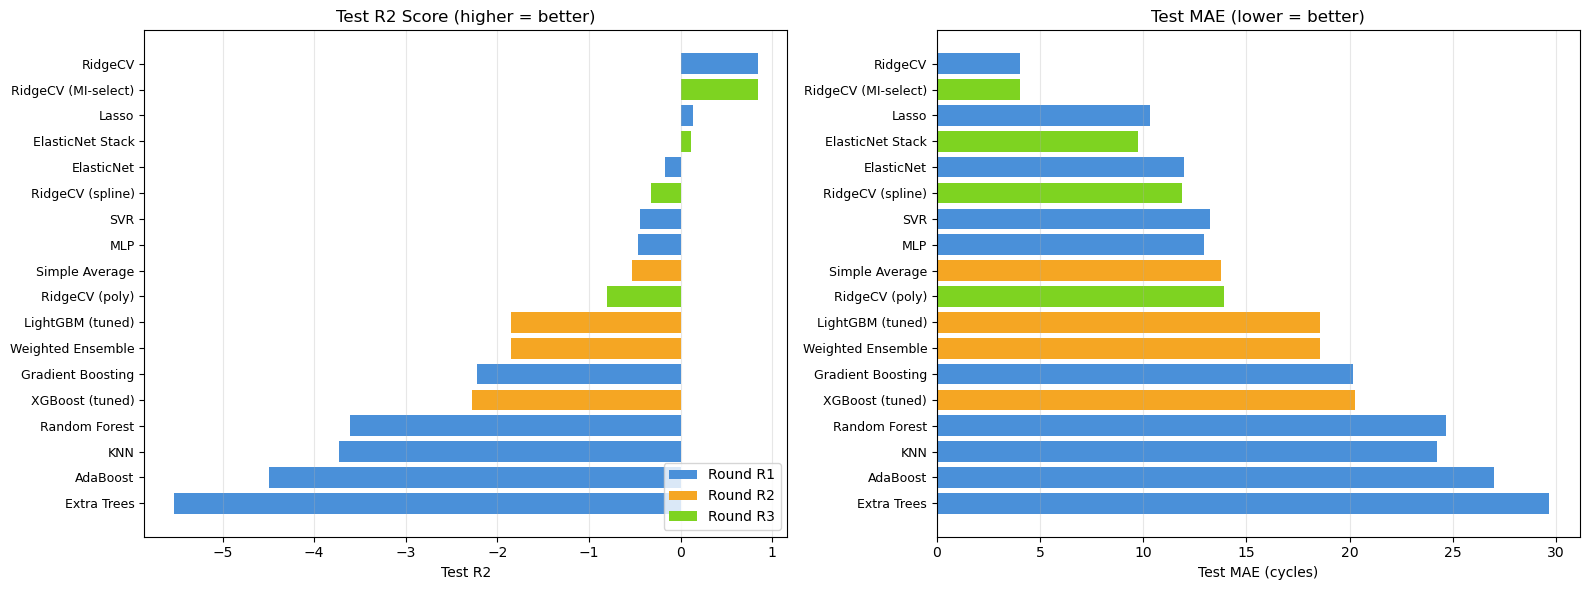

                    Round   R2_test        MAE       RMSE   Overfit
Model                                                              
RidgeCV                R1  0.846704   4.009178   4.877664   0.09669
RidgeCV (MI-select)    R3  0.845006   4.040862   4.904609  0.098374
Lasso                  R1  0.132471  10.354124  11.603496  0.776372
ElasticNet Stack       R3  0.114429   9.740695  11.723539  0.846304
ElasticNet             R1 -0.175484  11.972766   13.50689  1.067375
RidgeCV (spline)       R3 -0.320618  11.884795  14.316459  1.279879
SVR                    R1 -0.441559  13.246301  14.957642  1.420313
MLP                    R1  -0.46066  12.963868  15.056414  1.449664
Simple Average         R2 -0.536352  13.791192  15.441599  0.829627
RidgeCV (poly)         R3 -0.798912   13.89668  16.709058  1.605254
LightGBM (tuned)       R2 -1.847121   18.59327  21.020832   2.84599
Weighted Ensemble      R2 -1.847121   18.59327  21.020832  2.440033
Gradient Boosting      R1 -2.228129  20.160429  

In [11]:
# ============================================================
# RESULTS COMPARISON
# ============================================================
res_df = pd.DataFrame(results).T
res_df.index.name = 'Model'
res_df = res_df.sort_values('R2_test', ascending=False)

round_colors = {'R1': '#4A90D9', 'R2': '#F5A623', 'R3': '#7ED321'}
colors = [round_colors[r] for r in res_df['Round']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(len(res_df)), res_df['R2_test'], color=colors)
axes[0].set_yticks(range(len(res_df)))
axes[0].set_yticklabels(res_df.index, fontsize=9)
axes[0].set_xlabel('Test R2')
axes[0].set_title('Test R2 Score (higher = better)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(res_df)), res_df['MAE'], color=colors)
axes[1].set_yticks(range(len(res_df)))
axes[1].set_yticklabels(res_df.index, fontsize=9)
axes[1].set_xlabel('Test MAE (cycles)')
axes[1].set_title('Test MAE (lower = better)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'Round {r}') for r, c in round_colors.items()]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(res_df[['Round', 'R2_test', 'MAE', 'RMSE', 'Overfit']].to_string())

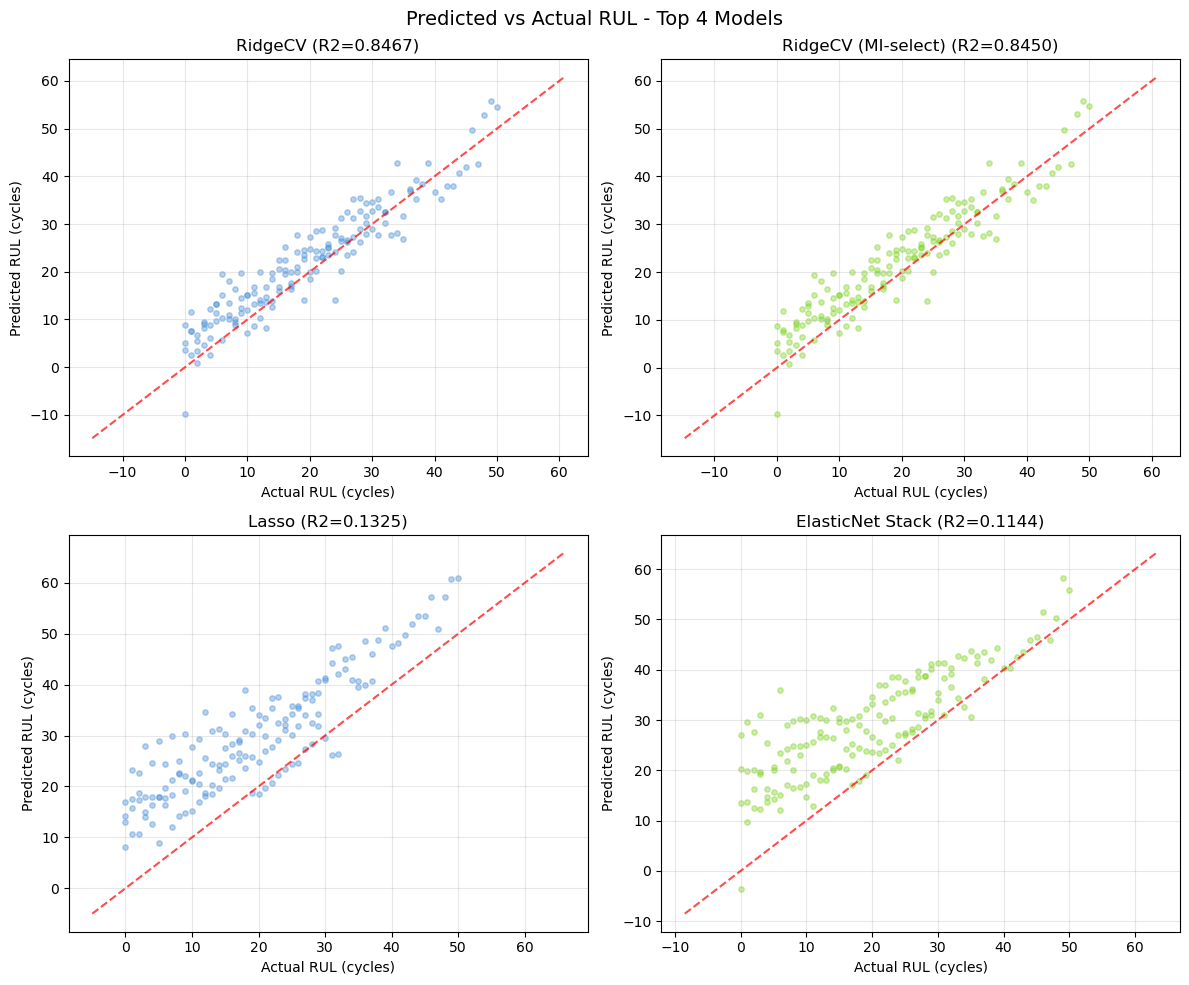

In [12]:
# scatter: predicted vs actual RUL for top 4
top4 = res_df.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name in zip(axes.flat, top4):
    pred = all_preds[name]
    ax.scatter(y_test, pred, alpha=0.4, s=15, c=round_colors[results[name]['Round']])
    mn, mx = min(y_test.min(), pred.min()) - 5, max(y_test.max(), pred.max()) + 5
    ax.plot([mn, mx], [mn, mx], 'r--', alpha=0.7)
    ax.set_xlabel('Actual RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f'{name} (R2={results[name]["R2_test"]:.4f})')
    ax.grid(True, alpha=0.3)
plt.suptitle('Predicted vs Actual RUL - Top 4 Models', fontsize=14)
plt.tight_layout()
plt.show()

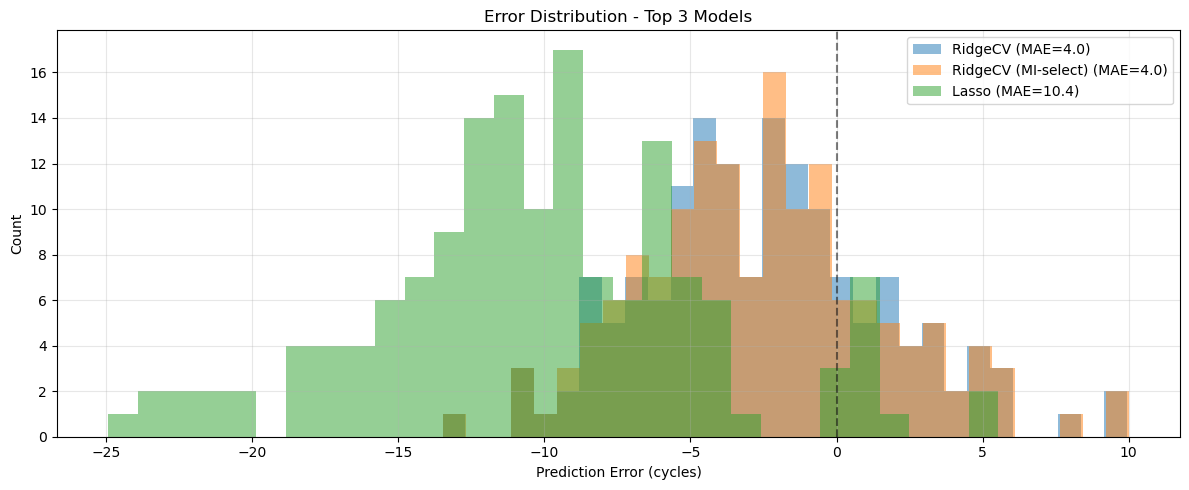

In [13]:
# error distribution for top 3
top3 = res_df.index[:3].tolist()
fig, ax = plt.subplots(figsize=(12, 5))
for name in top3:
    errors = y_test - all_preds[name]
    ax.hist(errors, bins=30, alpha=0.5, label=f'{name} (MAE={results[name]["MAE"]:.1f})')
ax.set_xlabel('Prediction Error (cycles)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution - Top 3 Models')
ax.legend()
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

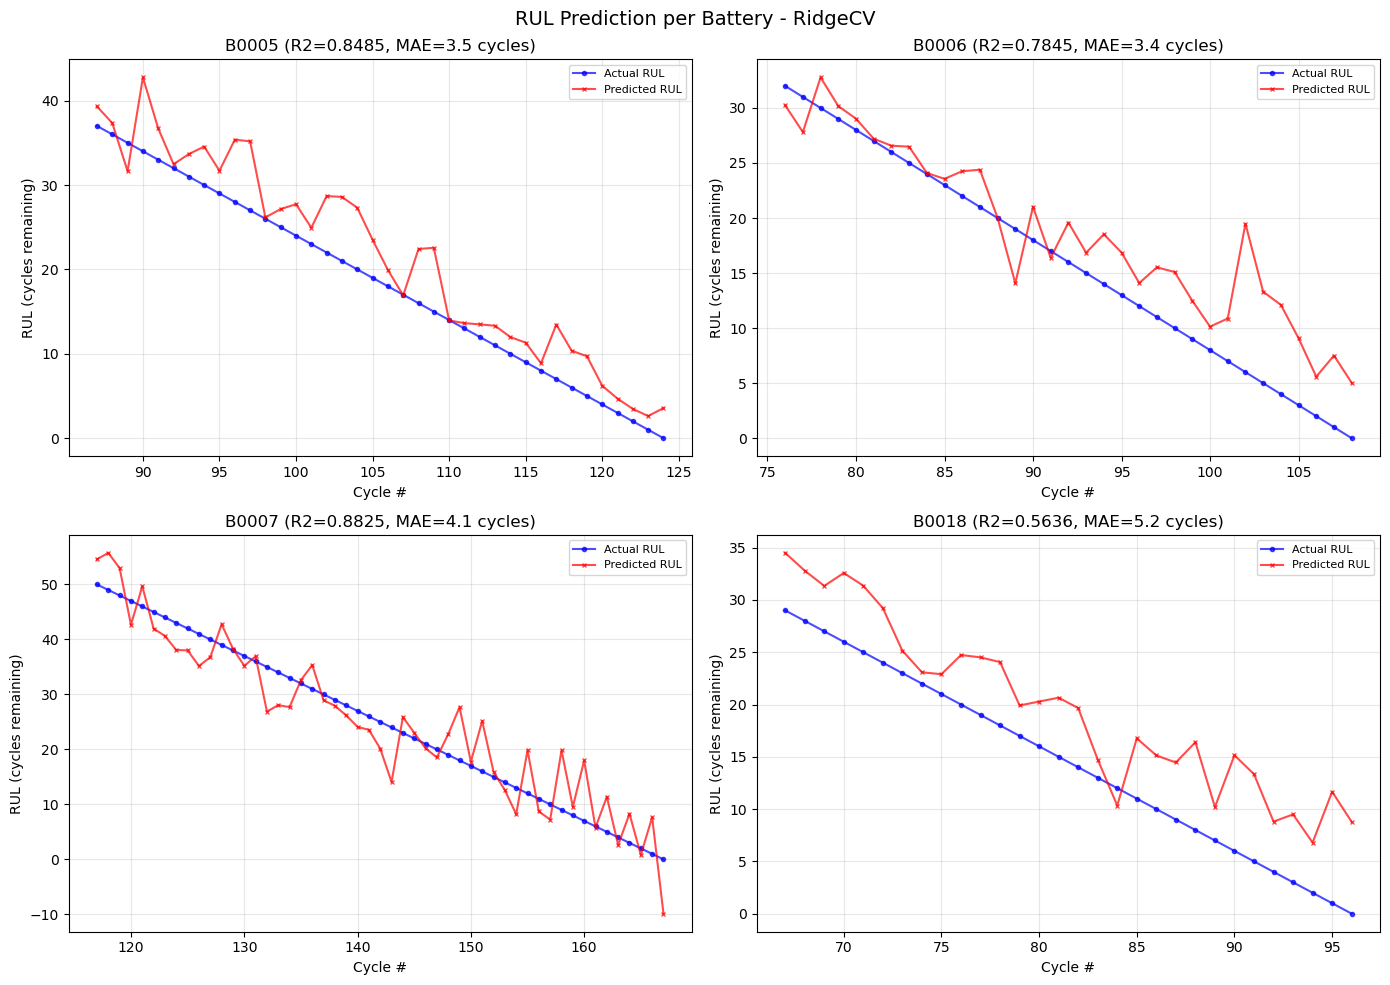

In [14]:
# RUL prediction over cycles for each test battery
best_model_name = res_df.index[0]
best_preds = all_preds[best_model_name]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, bid in zip(axes.flat, classic):
    mask = test_df['battery_id'] == bid
    cycles = test_df.loc[mask, 'cycle'].values
    actual = test_df.loc[mask, 'RUL'].values
    predicted = best_preds[mask.values]

    ax.plot(cycles, actual, 'b-o', markersize=3, label='Actual RUL', alpha=0.7)
    ax.plot(cycles, predicted, 'r-x', markersize=3, label='Predicted RUL', alpha=0.7)
    ax.set_xlabel('Cycle #')
    ax.set_ylabel('RUL (cycles remaining)')
    r2_bid = r2_score(actual, predicted)
    mae_bid = mean_absolute_error(actual, predicted)
    ax.set_title(f'{bid} (R2={r2_bid:.4f}, MAE={mae_bid:.1f} cycles)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'RUL Prediction per Battery - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

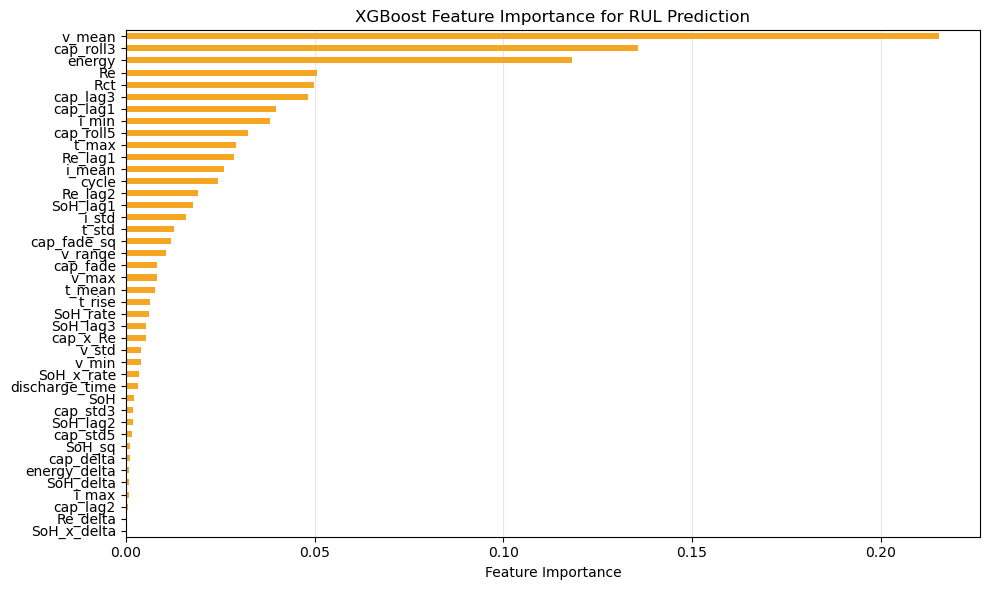

Top 5 features:
  v_mean              : 0.2155
  cap_roll3           : 0.1358
  energy              : 0.1183
  Re                  : 0.0508
  Rct                 : 0.0498


In [15]:
# feature importance
importances = xgb_best.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='#F5A623')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance for RUL Prediction')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:20s}: {imp:.4f}')

In [16]:
# final summary
print('=' * 80)
print('RUL PREDICTION BENCHMARK - FINAL RESULTS')
print('=' * 80)
print(f'Dataset: NASA Battery ({df_all.battery_id.nunique()} batteries, {len(df_all)} cycles)')
print(f'Split:   Hybrid (all non-classic + first 70% classic = train, last 30% classic = test)')
print(f'Train: {len(train_df)} samples ({train_df.battery_id.nunique()} batteries)')
print(f'Test:  {len(test_df)} samples (last 30% of {classic})')
print(f'Features: {len(feature_cols)} (SoH + degradation rate + lag + interaction features)')
print(f'Target: RUL (cycles remaining until capacity <= {EOL_THRESHOLD} Ah)')
print()
print(f'{"Model":30s} {"Round":5s} {"R2":>8s} {"MAE":>10s} {"RMSE":>10s} {"Overfit":>8s}')
print('-' * 80)
for name, row in res_df.iterrows():
    print(f'{name:30s} {row["Round"]:5s} {row["R2_test"]:8.4f} {row["MAE"]:8.1f} cy {row["RMSE"]:8.1f} cy {row["Overfit"]:+8.4f}')
print('-' * 80)
best = res_df.index[0]
print(f'\nBEST MODEL: {best}')
print(f'  R2: {results[best]["R2_test"]:.4f} | MAE: {results[best]["MAE"]:.1f} cycles | RMSE: {results[best]["RMSE"]:.1f} cycles')

RUL PREDICTION BENCHMARK - FINAL RESULTS
Dataset: NASA Battery (18 batteries, 806 cycles)
Split:   Hybrid (all non-classic + first 70% classic = train, last 30% classic = test)
Train: 654 samples (18 batteries)
Test:  152 samples (last 30% of ['B0005', 'B0006', 'B0007', 'B0018'])
Features: 42 (SoH + degradation rate + lag + interaction features)
Target: RUL (cycles remaining until capacity <= 1.4 Ah)

Model                          Round       R2        MAE       RMSE  Overfit
--------------------------------------------------------------------------------
RidgeCV                        R1      0.8467      4.0 cy      4.9 cy  +0.0967
RidgeCV (MI-select)            R3      0.8450      4.0 cy      4.9 cy  +0.0984
Lasso                          R1      0.1325     10.4 cy     11.6 cy  +0.7764
ElasticNet Stack               R3      0.1144      9.7 cy     11.7 cy  +0.8463
ElasticNet                     R1     -0.1755     12.0 cy     13.5 cy  +1.0674
RidgeCV (spline)               R3     -0.3